**Program No. 14.  >> Text Data Visualization**
**Objective:** To visualize textual data.
**Tasks:**
- Count word frequency from a paragraph
- Plot text visualization

**Outcome:** Students will understand basic text visualization techniques.


**Step 1:** Install Required Library

In [1]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Step 2:** Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import re

**Step 3:** Load and Prepare Dataset

In [4]:
df = pd.read_csv("student_extended.csv")

df.columns = df.columns.str.strip().str.lower()

In [5]:
print(df.columns)

Index(['student_id', 'roll_number', 'department', 'program', 'specialization',
       'gender', 'age', 'domicile_state', 'category', 'study_hours_per_day',
       'attendance_percentage', 'sgpa', 'percentage', 'teaching_method',
       'learning_style'],
      dtype='object')


In [6]:
# Combine text columns
text_data = (
    df["specialization"].astype(str) + " " +
    df["program"].astype(str) + " " +
    df["learning_style"].astype(str)
)

# Convert to single paragraph
text_corpus = " ".join(text_data)

**Step 4:** Clean Text

In [7]:
# Convert to lowercase
text_corpus = text_corpus.lower()

# Remove special characters
text_corpus = re.sub(r'[^a-z\s]', '', text_corpus)

# Split into words
words = text_corpus.split()

# Remove small words (optional)
words = [word for word in words if len(word) > 2]

**Step 5:** Word Frequency Count

In [8]:
word_freq = Counter(words)

# Get top 10 frequent words
top_words = word_freq.most_common(10)

print("Top 10 Most Frequent Words:")
print(top_words)

Top 10 Most Frequent Words:
[('mca', 413), ('auditory', 412), ('kinesthetic', 402), ('btech', 394), ('bca', 393), ('visual', 386), ('software', 250), ('engg', 250), ('cloud', 244), ('cyber', 241)]


**Step 6:** Bar Chart of Word Frequency

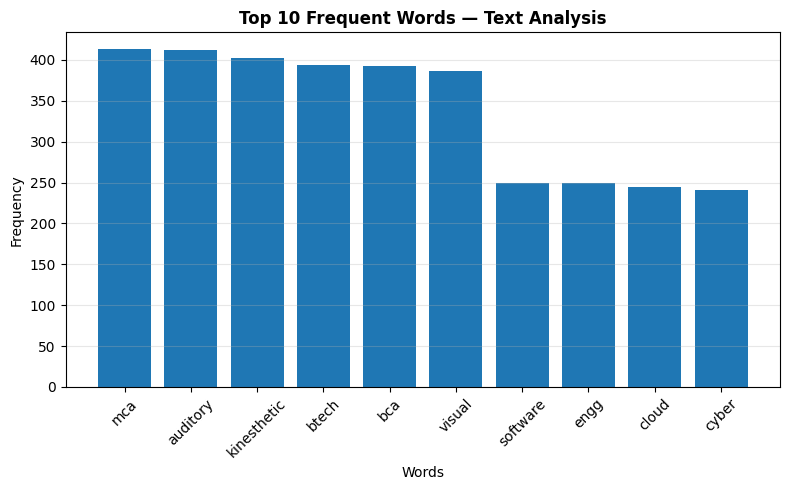

In [9]:
words_list, counts = zip(*top_words)

plt.figure(figsize=(8,5))
plt.bar(words_list, counts)

plt.title("Top 10 Frequent Words — Text Analysis", fontweight="bold")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Step 7:** Generate WordCloud

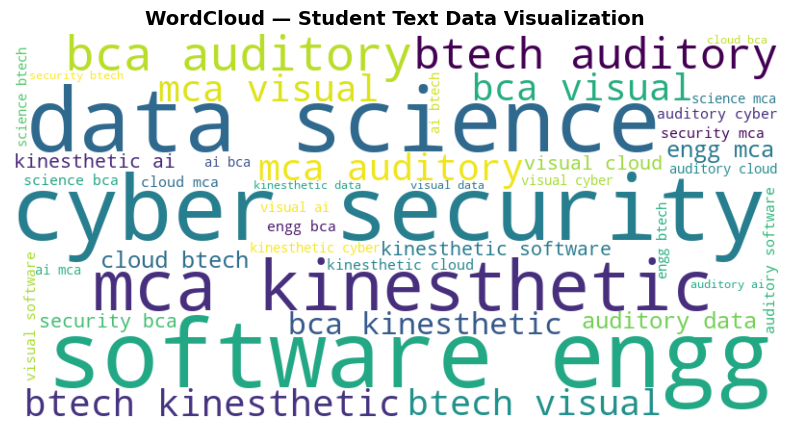

In [10]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis"
).generate(text_corpus)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

plt.title("WordCloud — Student Text Data Visualization",
          fontsize=14,
          fontweight="bold")

plt.show()

**From the text visualization:**
- Frequently occurring words indicate dominant academic trends.
- Specializations such as “cloud”, “ai”, “data”, or “cyber” may appear prominently.
- WordCloud visually emphasizes high-frequency words through larger font sizes.
- Bar chart provides precise numerical comparison.
- Text analysis helps in identifying institutional academic focus areas.